### Import Modules

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split, ConcatDataset
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

### Data Preprocessing

##### Load STL-10

In [ ]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

In [ ]:
train_data = datasets.STL10(root='./data', split='train', download=True, transform=transform)
test_data = datasets.STL10(root='./data', split='test', download=True, transform=transform)

full_data = ConcatDataset([train_data, test_data])

train_size = int(0.8 * len(full_data))
val_size = len(full_data) - train_size
train_data, val_data = random_split(full_data, [train_size, val_size])

stl_train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
stl_val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

100%|██████████| 2.64G/2.64G [01:45<00:00, 25.0MB/s]


Extracting ./data/stl10_binary.tar.gz to ./data
Files already downloaded and verified


In [ ]:
print(f"STL-10 Train: {len(stl_train_loader.dataset)}, Val: {len(stl_val_loader.dataset)}")

STL-10 Train: 10400, Val: 2600


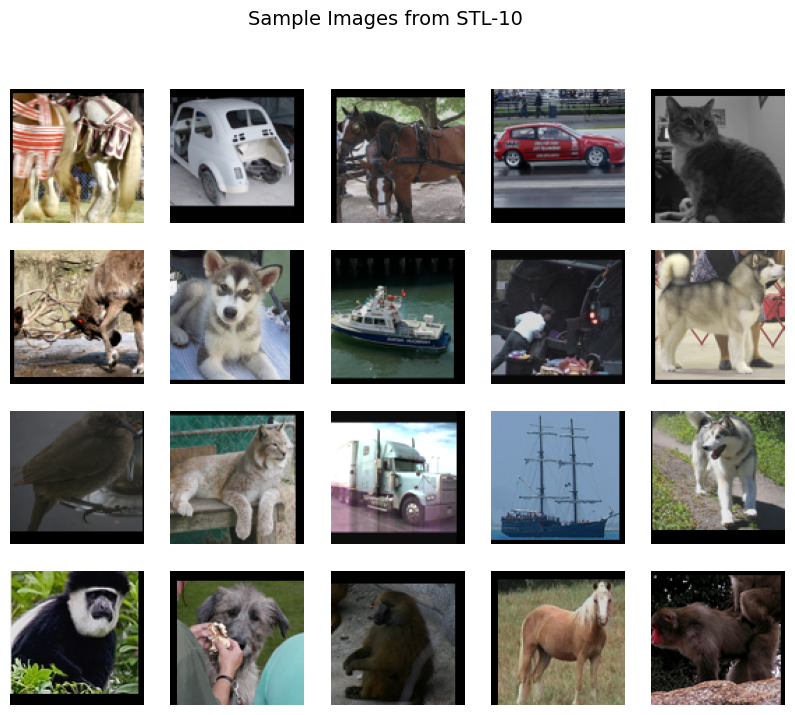

In [ ]:
data_iter = iter(stl_train_loader)
images, labels = next(data_iter)

fig, axes = plt.subplots(4, 5, figsize=(10, 8))
fig.suptitle(f"Sample Images from STL-10", fontsize=14)

for i, ax in enumerate(axes.flat):
    if i >= 20:
        break
    img = images[i].numpy().transpose(1, 2, 0)
    img = (img * 0.5) + 0.5
    ax.imshow(img)
    ax.axis('off')

plt.show()

##### Load MNIST

In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convert to 3-channel (to match STL-10)
    transforms.Resize((96, 96)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

In [ ]:
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_data, val_data = random_split(train_data, [train_size, val_size])

mnist_train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
mnist_val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
mnist_test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.55MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [ ]:
print(f"MNIST Train: {len(mnist_train_loader.dataset)}, Val: {len(mnist_val_loader.dataset)}, Test: {len(mnist_test_loader.dataset)}")

MNIST Train: 48000, Val: 12000, Test: 10000


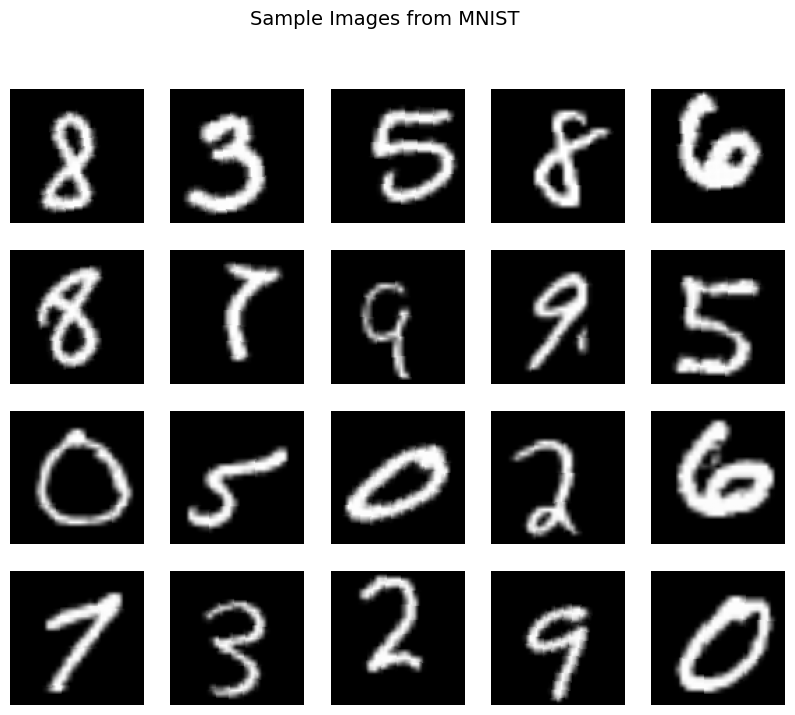

In [ ]:
data_iter = iter(mnist_train_loader)
images, labels = next(data_iter)

fig, axes = plt.subplots(4, 5, figsize=(10, 8))
fig.suptitle(f"Sample Images from MNIST", fontsize=14)

for i, ax in enumerate(axes.flat):
    if i >= 20:
        break
    img = images[i].numpy().transpose(1, 2, 0)
    img = (img * 0.5) + 0.5
    ax.imshow(img)
    ax.axis('off')

plt.show()

### Pretraining CNN on STL-10

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64, track_running_stats=False)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(128, track_running_stats=False)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(256, track_running_stats=False)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(512, track_running_stats=False)

        self.residual = nn.Conv2d(128, 256, kernel_size=1, stride=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.spatial_dropout = nn.Dropout2d(0.1)

        self.global_avg_pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = F.relu(self.bn2(self.conv2(x)))
        res = self.residual(x)
        x = self.pool(F.relu(self.bn3(self.conv3(x)) + res))
        x = self.spatial_dropout(x)
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, min_delta=1e-4):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    prev_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # stop training if validation loss stabilizes
        if abs(prev_val_loss - val_loss) < min_delta:
            print(f"Loss curve stabilized")
            break

        prev_val_loss = val_loss

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train vs Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()

    return model

Epoch 1/25 - Train Loss: 1.6870, Train Acc: 0.3563, Val Loss: 1.5440, Val Acc: 0.3969
Epoch 2/25 - Train Loss: 1.4188, Train Acc: 0.4745, Val Loss: 1.3727, Val Acc: 0.4981
Epoch 3/25 - Train Loss: 1.2827, Train Acc: 0.5227, Val Loss: 1.2727, Val Acc: 0.5446
Epoch 4/25 - Train Loss: 1.1910, Train Acc: 0.5614, Val Loss: 1.2578, Val Acc: 0.5600
Epoch 5/25 - Train Loss: 1.1321, Train Acc: 0.5887, Val Loss: 1.1725, Val Acc: 0.5827
Epoch 6/25 - Train Loss: 1.0660, Train Acc: 0.6121, Val Loss: 1.0610, Val Acc: 0.6369
Epoch 7/25 - Train Loss: 1.0169, Train Acc: 0.6333, Val Loss: 1.0298, Val Acc: 0.6285
Epoch 8/25 - Train Loss: 0.9767, Train Acc: 0.6444, Val Loss: 1.0270, Val Acc: 0.6342
Epoch 9/25 - Train Loss: 0.9377, Train Acc: 0.6591, Val Loss: 0.9617, Val Acc: 0.6673
Epoch 10/25 - Train Loss: 0.8895, Train Acc: 0.6787, Val Loss: 0.9406, Val Acc: 0.6723
Epoch 11/25 - Train Loss: 0.8510, Train Acc: 0.6964, Val Loss: 0.9499, Val Acc: 0.6673
Epoch 12/25 - Train Loss: 0.8349, Train Acc: 0.7039,

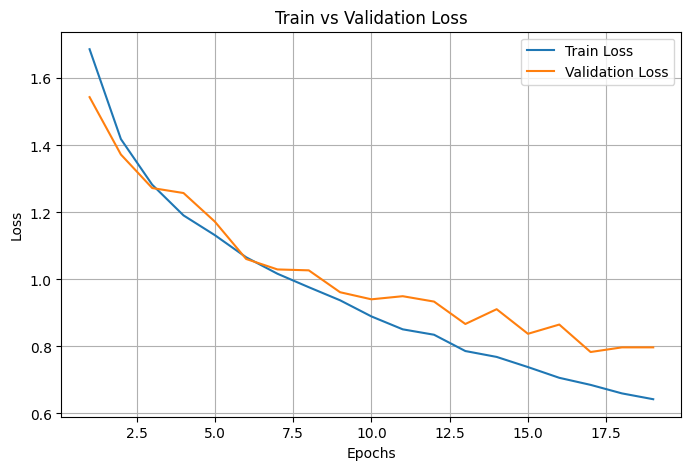

In [ ]:
model = CNN()
trained_model = train_model(model, stl_train_loader, stl_val_loader, epochs=25)

### Transfer Learning

In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted")
    cm = confusion_matrix(all_labels, all_preds)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

##### 1. Training linear layers only

In [ ]:
m1_model = trained_model
m1_model.to(device)

# freeze all layers except the final FC layer
for param in m1_model.parameters():
    param.requires_grad = False

# ensure FC layer is trainable
for param in m1_model.fc.parameters():
    param.requires_grad = True

Epoch 1/50 - Train Loss: 1.5286, Train Acc: 0.4942, Val Loss: 1.0295, Val Acc: 0.6928
Epoch 2/50 - Train Loss: 1.0067, Train Acc: 0.6879, Val Loss: 0.8323, Val Acc: 0.7570
Epoch 3/50 - Train Loss: 0.8783, Train Acc: 0.7318, Val Loss: 0.7300, Val Acc: 0.7984
Epoch 4/50 - Train Loss: 0.7906, Train Acc: 0.7640, Val Loss: 0.6568, Val Acc: 0.8229
Epoch 5/50 - Train Loss: 0.7340, Train Acc: 0.7813, Val Loss: 0.6143, Val Acc: 0.8315
Epoch 6/50 - Train Loss: 0.6896, Train Acc: 0.7963, Val Loss: 0.5677, Val Acc: 0.8465
Epoch 7/50 - Train Loss: 0.6533, Train Acc: 0.8086, Val Loss: 0.5438, Val Acc: 0.8540
Epoch 8/50 - Train Loss: 0.6254, Train Acc: 0.8169, Val Loss: 0.5217, Val Acc: 0.8567
Epoch 9/50 - Train Loss: 0.5981, Train Acc: 0.8252, Val Loss: 0.4971, Val Acc: 0.8625
Epoch 10/50 - Train Loss: 0.5850, Train Acc: 0.8293, Val Loss: 0.4956, Val Acc: 0.8629
Epoch 11/50 - Train Loss: 0.5633, Train Acc: 0.8358, Val Loss: 0.4644, Val Acc: 0.8704
Epoch 12/50 - Train Loss: 0.5495, Train Acc: 0.8392,

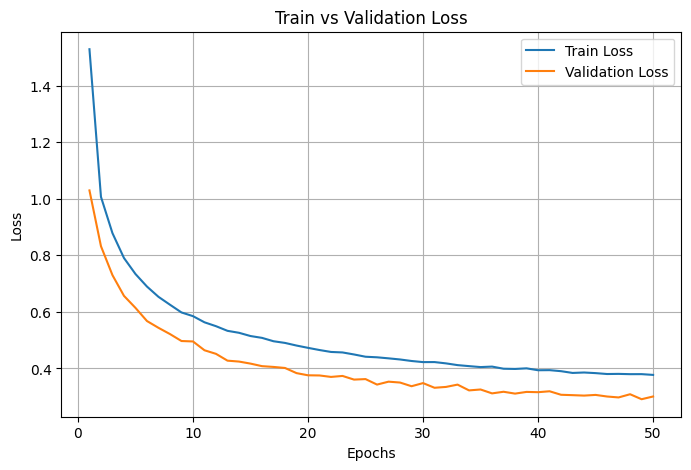

In [ ]:
m1_model = train_model(m1_model, mnist_train_loader, mnist_val_loader)

Accuracy: 0.9278
Precision: 0.9289, Recall: 0.9278, F1-score: 0.9279


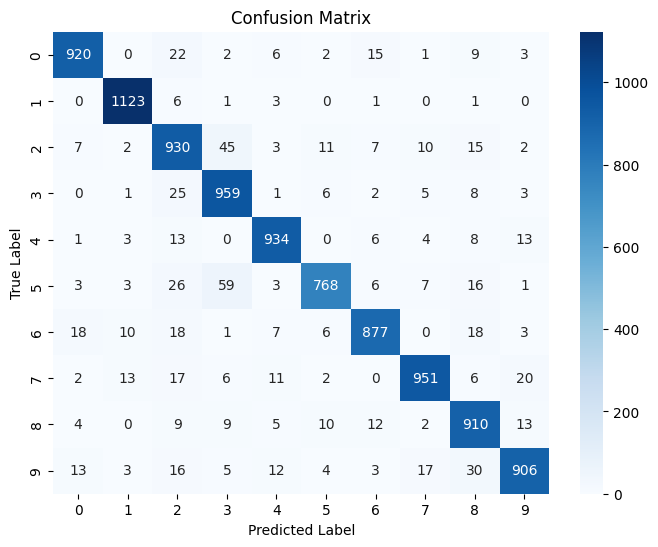

In [ ]:
evaluate_model(m1_model, mnist_test_loader)

##### 2. Freeze initial layers and fine tune

In [ ]:
m2_model = trained_model
m2_model.to(device)

# unfreeze only last few layers
for name, param in m2_model.named_parameters():
    if "conv" in name and "2" in name:
        param.requires_grad = True
    elif "conv" in name and "3" in name:
        param.requires_grad = True
    elif "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

Epoch 1/50 - Train Loss: 0.1656, Train Acc: 0.9493, Val Loss: 0.0900, Val Acc: 0.9726
Epoch 2/50 - Train Loss: 0.1098, Train Acc: 0.9674, Val Loss: 0.0682, Val Acc: 0.9803
Epoch 3/50 - Train Loss: 0.0934, Train Acc: 0.9721, Val Loss: 0.0650, Val Acc: 0.9812
Epoch 4/50 - Train Loss: 0.0849, Train Acc: 0.9741, Val Loss: 0.0631, Val Acc: 0.9816
Epoch 5/50 - Train Loss: 0.0769, Train Acc: 0.9773, Val Loss: 0.0607, Val Acc: 0.9813
Epoch 6/50 - Train Loss: 0.0737, Train Acc: 0.9779, Val Loss: 0.0581, Val Acc: 0.9829
Epoch 7/50 - Train Loss: 0.0678, Train Acc: 0.9794, Val Loss: 0.0545, Val Acc: 0.9832
Epoch 8/50 - Train Loss: 0.0655, Train Acc: 0.9808, Val Loss: 0.0517, Val Acc: 0.9852
Epoch 9/50 - Train Loss: 0.0645, Train Acc: 0.9801, Val Loss: 0.0480, Val Acc: 0.9865
Epoch 10/50 - Train Loss: 0.0629, Train Acc: 0.9808, Val Loss: 0.0485, Val Acc: 0.9845
Epoch 11/50 - Train Loss: 0.0601, Train Acc: 0.9819, Val Loss: 0.0452, Val Acc: 0.9869
Epoch 12/50 - Train Loss: 0.0598, Train Acc: 0.9814,

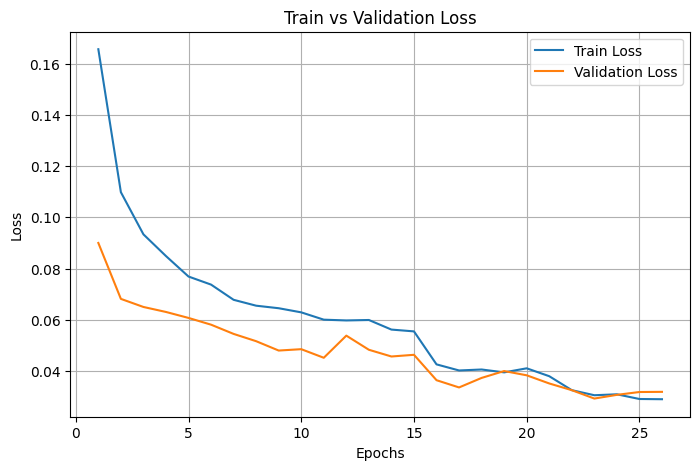

In [ ]:
m2_model = train_model(m2_model, mnist_train_loader, mnist_val_loader)

Accuracy: 0.9913
Precision: 0.9913, Recall: 0.9913, F1-score: 0.9913


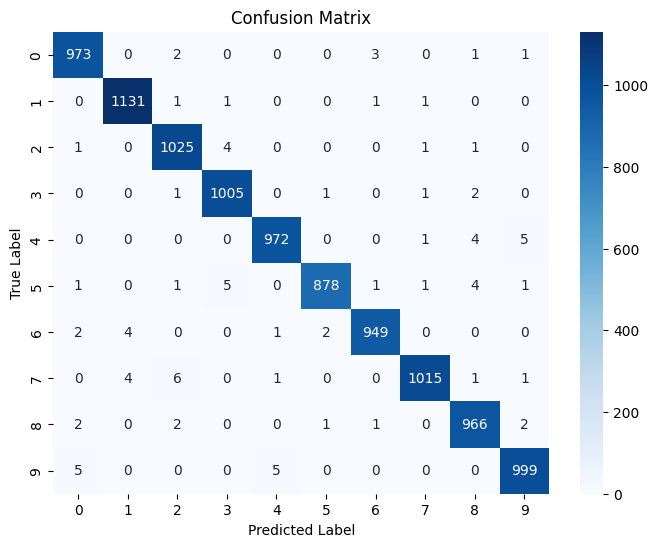

In [ ]:
evaluate_model(m2_model, mnist_test_loader)

##### 3. Finetune entire network

In [ ]:
m3_model = trained_model
m3_model.to(device)

for name, param in m3_model.named_parameters():
    param.requires_grad = True

Epoch 1/50 - Train Loss: 0.0857, Train Acc: 0.9752, Val Loss: 0.0819, Val Acc: 0.9765
Epoch 2/50 - Train Loss: 0.0635, Train Acc: 0.9816, Val Loss: 0.0684, Val Acc: 0.9819
Epoch 3/50 - Train Loss: 0.0565, Train Acc: 0.9827, Val Loss: 0.0545, Val Acc: 0.9835
Epoch 4/50 - Train Loss: 0.0541, Train Acc: 0.9836, Val Loss: 0.0465, Val Acc: 0.9865
Epoch 5/50 - Train Loss: 0.0495, Train Acc: 0.9848, Val Loss: 0.0637, Val Acc: 0.9813
Epoch 6/50 - Train Loss: 0.0490, Train Acc: 0.9848, Val Loss: 0.0397, Val Acc: 0.9886
Epoch 7/50 - Train Loss: 0.0473, Train Acc: 0.9855, Val Loss: 0.0415, Val Acc: 0.9878
Epoch 8/50 - Train Loss: 0.0443, Train Acc: 0.9868, Val Loss: 0.0347, Val Acc: 0.9894
Epoch 9/50 - Train Loss: 0.0443, Train Acc: 0.9860, Val Loss: 0.0327, Val Acc: 0.9898
Epoch 10/50 - Train Loss: 0.0431, Train Acc: 0.9864, Val Loss: 0.0393, Val Acc: 0.9885
Epoch 11/50 - Train Loss: 0.0421, Train Acc: 0.9869, Val Loss: 0.0412, Val Acc: 0.9877
Epoch 12/50 - Train Loss: 0.0423, Train Acc: 0.9871,

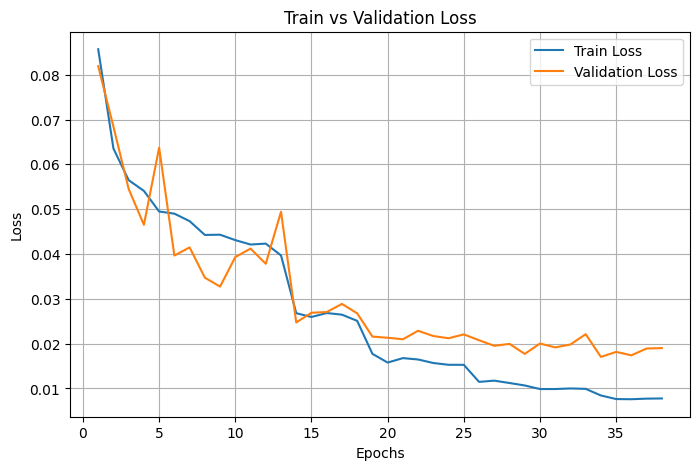

In [ ]:
m3_model = train_model(m3_model, mnist_train_loader, mnist_val_loader)

Accuracy: 0.9939
Precision: 0.9939, Recall: 0.9939, F1-score: 0.9939


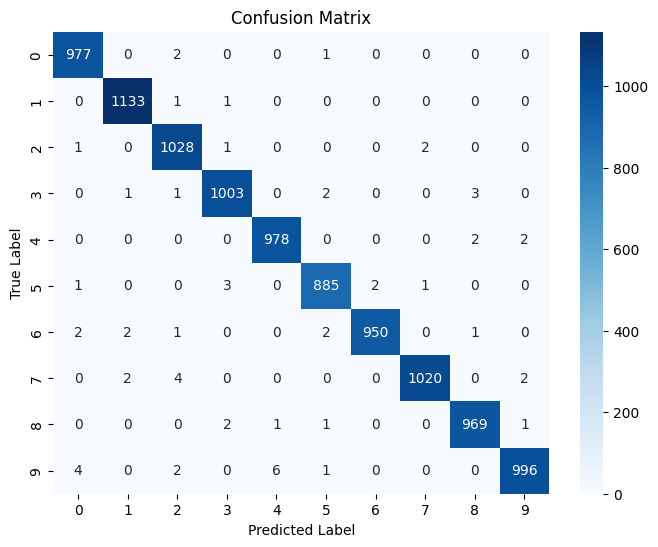

In [ ]:
evaluate_model(m3_model, mnist_test_loader)